# BME Lab 114 — Morphology-Elasticity Relationship of Trabecular Bone

**Author:** Simone Poncioni, MSB  
**Date:** Spring Semester 2026

---

## Notebook 4: Post-processing

The CalculiX solver has produced a `.frd` results file containing nodal displacements, reaction forces, and element stresses. In this final notebook, we extract these results and use them to compute two key quantities:

1. The **apparent elastic modulus** $E_\text{app}$ — a measure of the overall stiffness of the trabecular structure
2. The **bone volume fraction** BV/TV — the primary morphological descriptor of trabecular bone density

Finally, we visualise the stress and strain fields across the mesh to gain intuition about how load is distributed through the trabecular network.

### 0. Imports

In [16]:
from pathlib import Path
import ccx2paraview
import pyvista as pv
import numpy as np
import meshio
import pandas as pd
import os

### 1. Convert CalculiX Output to VTK

The solver writes results in its native `.frd` binary format. We first convert it to `.vtk` using `ccx2paraview`, which makes the data readable by PyVista and other visualisation tools.

We also read the `.dat` file, which contains the **printed scalar outputs** requested in the simulation template — in our case, the total reaction force at the bottom face (`RF` at `NODES_Z0`).

In [17]:
filename_frd = Path("/home/bmelab/bmelabs/2026/testing/MSB_BMELab/114-MorphologyElasticityTrabecularBone/muFE/00_DATA/group01/A1/derived/C0004351_segmented.frd")
filename_dat = filename_frd.with_suffix(".dat")
filename_vtk = filename_frd.with_suffix(".vtk")
filename_np = filename_frd.with_suffix(".npy")

ccx2paraview.Converter(str(filename_frd.resolve()), ['vtk']).run()

The `.dat` file contains the sum of reaction forces at the fixed boundary. Read it carefully — you will need the total reaction force $F$ to compute the apparent elastic modulus in the next step.

In [18]:
!cat {filename_dat}


 total force (fx,fy,fz) for set NODES_Z0 and time  0.1000000E+01

        2.658636E-11  5.915921E-12  5.362209E+02


### 2. Calculate the Apparent Elastic Modulus

The apparent elastic modulus is defined as:

$$E_\text{app} = \frac{\sigma}{\varepsilon} = \frac{F / A}{\Delta u / L}$$

Where:
- $F$ — total reaction force at the fixed face [N], read from the `.dat` file
- $A$ — cross-sectional area of the sample [mm²], computed from the mesh bounding box
- $\Delta u$ — applied displacement [mm], as defined in the simulation template
- $L$ — height of the sample along the loading axis [mm]

> **Task:** Complete the code below to extract $F$, $A$, $L$, and compute $E_\text{app}$.

> **Reference:** [`np.loadtxt`](https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html), [`np.sum`](https://numpy.org/doc/stable/reference/generated/numpy.sum.html)

In [19]:
mesh = meshio.read(filename_vtk)

# Get bounding box from mesh points
points = mesh.points  # shape (N, 3) → columns: X, Y, Z
L = points[:, 2].max() - points[:, 2].min()  # height along Z [mm]
print(L)

# TODO: Read the total reaction force F from filename_dat
F = 536.2209
# TODO: Input the cross-sectional area A of the sample
A = np.pi * 7**2
du = 0.01
# TODO: Compute apparent strain, stress, and elastic modulus
sigma = F/A
epsilon = du/L
E_app = sigma/epsilon
stiffness = F/du

print(f"Reaction force F     = {F:.4f} N")
print(f"Cross-section A      = {A:.4f} mm²")
print(f"Sample height L      = {L:.4f} mm")
print(f"Stiffness            = {stiffness:.2f} N/mm")
print(f"Apparent strain ε    = {epsilon:.6f}")
print(f"Apparent stress σ    = {sigma:.4f} MPa")
print(f"Apparent modulus E   = {E_app:.2f} MPa")

14.8605
Reaction force F     = 536.2209 N
Cross-section A      = 153.9380 mm²
Sample height L      = 14.8605 mm
Stiffness            = 53622.09 N/mm
Apparent strain ε    = 0.000673
Apparent stress σ    = 3.4834 MPa
Apparent modulus E   = 5176.44 MPa


### 3. Calculate Bone Volume Fraction (BV/TV)

Bone Volume Fraction (BV/TV) is the ratio of mineralised bone volume to the total volume of the region of interest. It is the single most important morphological predictor of trabecular bone stiffness.

$$\text{BV/TV} = \frac{\text{Number of bone voxels}}{\text{Total number of voxels in ROI}}$$

> **Task:** Complete the code below to compute BV/TV from the segmented image `bone_arr` produced in Notebook 1.  
> **Reference:** [`np.sum`](https://numpy.org/doc/stable/reference/generated/numpy.sum.html), [`np.prod`](https://numpy.org/doc/stable/reference/generated/numpy.prod.html), [`ndarray.shape`](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.shape.html)

In [20]:
bone_np = np.load(filename_np)
print(bone_np.shape)

x = bone_np.shape[0]
y = bone_np.shape[1]
z = bone_np.shape[2]
av = (x+y)/4
V = np.pi * av**2 * z

# TODO: Calculate TV (total number of voxels in the bounding box)
TV = np.prod(bone_np.shape)
# TODO: Calculate BV (number of bone voxels, where bone = 1)
BV = np.sum(bone_np)
# TODO: Calculate BV/TV
BVTV = BV/TV
BVTV2 = BV/V

print(f"TV       = {TV} voxels")
print(f"BV       = {BV} voxels")
print(f"BV/TV    = {BVTV:.4f}  ({BVTV * 100:.2f} %)")
print(f"BV/TV from cylinder   = {BVTV2:.4f}  ({BVTV2 * 100:.2f} %)")

(532, 453, 477)
TV       = 114955092 voxels
BV       = 34107594 voxels
BV/TV    = 0.2967  (29.67 %)
BV/TV from cylinder   = 0.3753  (37.53 %)


In [21]:
mesh = pv.read(filename_vtk)
print(mesh.array_names)  # shows available scalar arrays

['U', 'S', 'S_Mises', 'S_Principal', 'E', 'E_Mises', 'E_Principal', 'ERROR']


nvc0_screen_create:899 - Base screen init failed: -19
libEGL warning: egl: failed to create dri2 screen
nvc0_screen_create:899 - Base screen init failed: -19
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-03-19 16:49:21.723 (1503.497s) [    7FFA28BBD740] vtkEGLRenderWindow.cxx:359   WARN| vtkEGLRenderWindow (0x256574e0): EGL device index: 0 could not be initialized. Trying other devices...
nvc0_screen_create:899 - Base screen init failed: -19
libEGL warning: egl: failed to create dri2 screen
nvc0_screen_create:899 - Base screen init failed: -19
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-03-19 16:49:21.737 (1503.511s) [    7FFA28BBD740] vtkEGLRenderWindow.cxx:359   WARN| vtkEGLRenderWindow (0x28f63100): EGL device index: 0 could not be initialized. Trying other devices...
/home/bmelab/.conda/envs/bmelabs25/lib/python3.11/site-packages/py

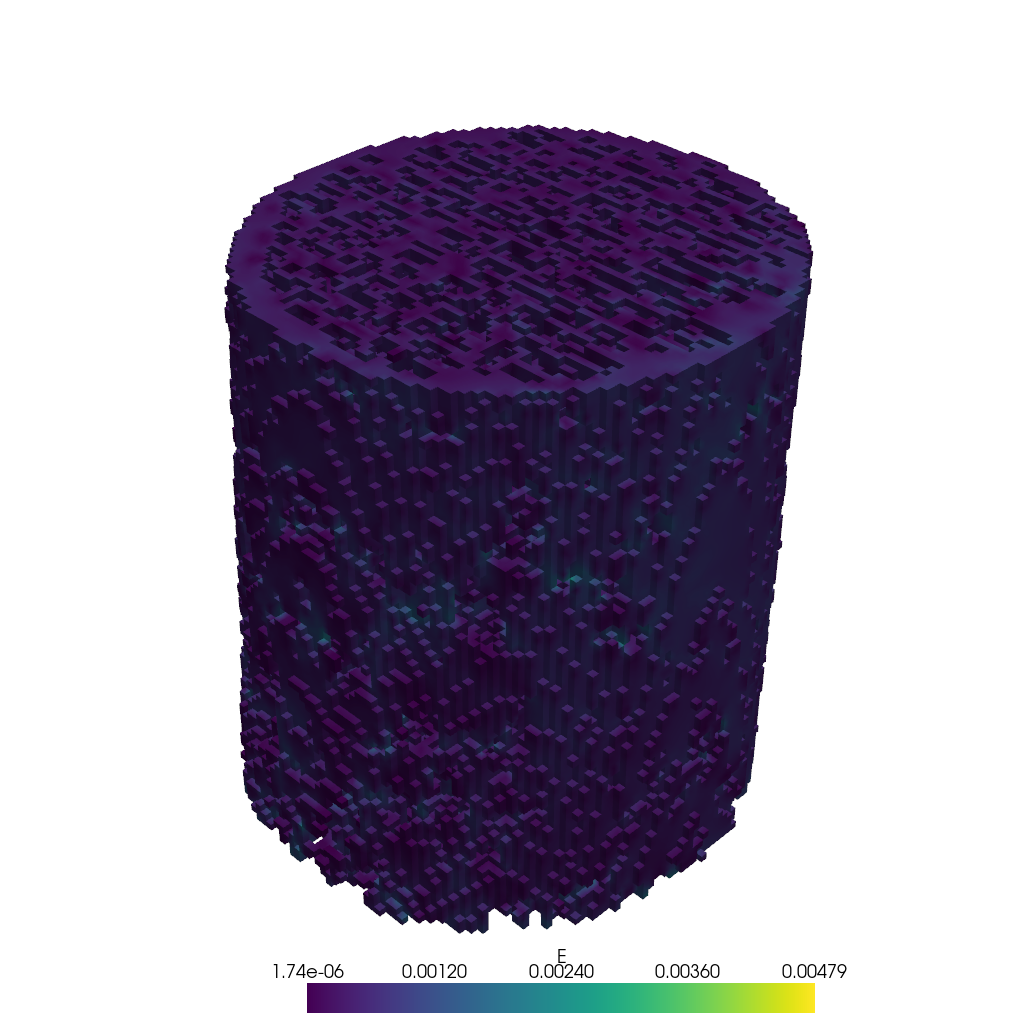

In [22]:
# Opens interactive viewer in browser/Jupyter cell
pv.global_theme.colorbar_horizontal.width = 0.5
pv.global_theme.colorbar_horizontal.position_x = 0.3
pv.global_theme.colorbar_horizontal.position_y = 0.01
pl = pv.Plotter(window_size=[1024, 1024])
pl.add_mesh(mesh, scalars="E", cmap="viridis")
pl.show()

In [23]:
row = {
    "sample": filename_frd.name.split("_")[0],
    "bvtv": BVTV,
    "reaction_force_N": round(F, 4),
    "stiffness_Nmm": round(stiffness, 2),
    "app_strain": round(epsilon, 6),
    "app_stress_mpa": round(sigma, 4),
    "app_modulus_mpa": round(E_app, 2)
}

output_path = "../../02_RESULTS/results_group01.tsv"
df = pd.DataFrame([row])

# Write header only if file doesn't exist yet
df.to_csv(output_path, mode='a', header=not os.path.exists(output_path), index=False, sep = '\t', encoding='utf-8')